# Amazon Business Analytics

## Preparing EDA

### 1.1 Importing Data

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid")

In [68]:
amazon = pd.read_csv('../../Data/AmazonData/Amazon Sale Report.csv', low_memory=False)

### 1.2 Preparing Data Cleaning

In [69]:
amazon.shape

(128975, 24)

In [70]:
amazon.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [71]:
amazon.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


There are some missing values in Courier Status, Currency, Amount, ship-city, ship-state, ship-postal code, ship-country. City-State-Postal and Country have the same number of null vals.

In [72]:
amazon.nunique().to_frame(name='Count of unique values')

,Count of unique values
index,128975
Order ID,120378
Date,91
Status,13
Fulfilment,2
Sales Channel,2
ship-service-level,2
Style,1377
SKU,7195
Category,9


In [73]:
categorical_col = [col for col in amazon.columns
                   if amazon[col].nunique() <= 10]

In [74]:
categorical_col

['Fulfilment',
 'Sales Channel ',
 'ship-service-level',
 'Category',
 'Courier Status',
 'Qty',
 'currency',
 'ship-country',
 'B2B',
 'fulfilled-by',
 'Unnamed: 22']

In [75]:
amazon[categorical_col].apply(pd.unique).to_frame(name='Unique Values')

,Unique Values
Fulfilment,"[Merchant, Amazon]"
Sales Channel,"[Amazon.in, Non-Amazon]"
ship-service-level,"[Standard, Expedited]"
Category,"[Set, kurta, Western Dress, Top, Ethnic Dress,..."
Courier Status,"[nan, Shipped, Cancelled, Unshipped]"
Qty,"[0, 1, 2, 15, 3, 9, 13, 5, 4, 8]"
currency,"[INR, nan]"
ship-country,"[IN, nan]"
B2B,"[False, True]"
fulfilled-by,"[Easy Ship, nan]"


In [76]:
amazon[categorical_col[1]].value_counts()

Sales Channel 
Amazon.in     128851
Non-Amazon       124
Name: count, dtype: int64

In [77]:
amazon.describe().T

,count,mean,std,min,25%,50%,75%,max
index,128975.0,64487.000000,37232.019822,0.0,32243.5,64487.0,96730.5,128974.0
Qty,128975.0,0.904431,0.313354,0.0,1.0,1.0,1.0,15.0
Amount,121180.0,648.561465,281.211687,0.0,449.0,605.0,788.0,5584.0
ship-postal-code,128942.0,463966.236509,191476.764941,110001.0,382421.0,500033.0,600024.0,989898.0


In [78]:
amazon.describe(include='O')

C:\Users\fhdaa\AppData\Local\Temp\ipykernel_26156\2581729941.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  amazon.describe(include='O')


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,currency,ship-city,ship-state,ship-country,promotion-ids,fulfilled-by,Unnamed: 22
count,128975,128975,128975,128975,128975,128975,128975,128975,128975,128975,128975,122103,121180,128942,128942,128942,79822,39277,79925
unique,120378,91,13,2,2,2,1377,7195,9,11,7190,3,1,8955,69,1,5787,1,1
top,403-4984515-8861958,05-03-22,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-L,Set,M,B09SDXFFQ1,Shipped,INR,BENGALURU,MAHARASHTRA,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,Easy Ship,False
freq,12,2085,77804,89698,128851,88615,4224,773,50284,22711,773,109487,121180,11217,22260,128942,46100,39277,79925


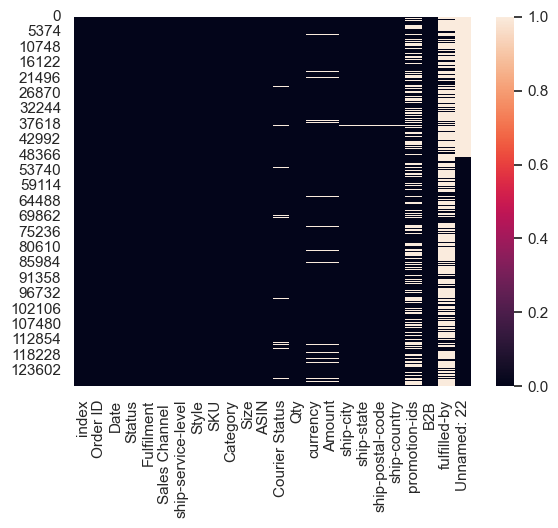

In [79]:
    sns.heatmap(amazon.isnull())
    plt.show()

In [80]:
amazon.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

### Data Cleaning

In [81]:
amazon.drop(columns=['index','Unnamed: 22','fulfilled-by','ship-country','currency','Sales Channel '],inplace=True)

In [82]:
amazon

,Order ID,Date,Status,Fulfilment,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,promotion-ids,B2B
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,647.62,MUMBAI,MAHARASHTRA,400081.0,NaN,False
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.00,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,False
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN Core Free Shipping 2015/04/08 23-48-5-108,True
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,NaN,False
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.00,CHENNAI,TAMIL NADU,600073.0,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128970,406-6001380-7673107,05-31-22,Shipped,Amazon,Expedited,JNE3697,JNE3697-KR-XL,kurta,XL,B098112V2V,Shipped,1,517.00,HYDERABAD,TELANGANA,500013.0,NaN,False
128971,402-9551604-7544318,05-31-22,Shipped,Amazon,Expedited,SET401,SET401-KR-NP-M,Set,M,B09VC6KHX8,Shipped,1,999.00,GURUGRAM,HARYANA,122004.0,IN Core Free Shipping 2015/04/08 23-48-5-108,False
128972,407-9547469-3152358,05-31-22,Shipped,Amazon,Expedited,J0157,J0157-DR-XXL,Western Dress,XXL,B0982YZ51B,Shipped,1,690.00,HYDERABAD,TELANGANA,500049.0,NaN,False
128973,402-6184140-0545956,05-31-22,Shipped,Amazon,Expedited,J0012,J0012-SKD-XS,Set,XS,B0894Y2NJQ,Shipped,1,1199.00,Halol,Gujarat,389350.0,IN Core Free Shipping 2015/04/08 23-48-5-108,False


In [83]:
amazon[amazon.duplicated(['Order ID','ASIN'], keep=False)]

,Order ID,Date,Status,Fulfilment,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,promotion-ids,B2B
30660,406-0372545-6086735,04-12-22,Cancelled,Amazon,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,NaN,Siliguri,WEST BENGAL,734008.0,NaN,False
30661,406-0372545-6086735,04-12-22,Cancelled,Amazon,Expedited,SET197,SET197-KR-NP-L,Set,L,B08B3YPD63,Cancelled,0,NaN,Siliguri,WEST BENGAL,734008.0,NaN,False
41291,408-0373839-4433120,04-05-22,Cancelled,Amazon,Expedited,JNE3501,JNE3501-KR-M,kurta,M,B08MYVCDB4,Cancelled,0,NaN,BENGALURU,KARNATAKA,560072.0,NaN,False
41292,408-0373839-4433120,04-05-22,Cancelled,Amazon,Expedited,JNE3501,JNE3501-KR-M,kurta,M,B08MYVCDB4,Cancelled,0,NaN,BENGALURU,KARNATAKA,560072.0,NaN,False
52330,407-8364731-6449117,05-29-22,Shipped,Amazon,Expedited,JNE3769,JNE3769-KR-L,kurta,L,B09K3T675B,Cancelled,0,NaN,Theni,TAMIL NADU,625579.0,IN Core Free Shipping 2015/04/08 23-48-5-108,False
52333,407-8364731-6449117,05-29-22,Shipped,Amazon,Expedited,JNE3769,JNE3769-KR-L,kurta,L,B09K3T675B,Shipped,1,487.0,Theni,TAMIL NADU,625579.0,IN Core Free Shipping 2015/04/08 23-48-5-108,False
79844,171-9628368-5329958,05-07-22,Cancelled,Amazon,Expedited,J0329,J0329-KR-L,kurta,L,B09KXRB7JV,Cancelled,0,NaN,ERNAKULAM,KERALA,682017.0,NaN,False
79845,171-9628368-5329958,05-07-22,Cancelled,Amazon,Expedited,J0329,J0329-KR-L,kurta,L,B09KXRB7JV,Cancelled,0,NaN,ERNAKULAM,KERALA,682017.0,NaN,False
85790,171-3249942-2207542,05-03-22,Shipped,Amazon,Expedited,SET323,SET323-KR-NP-XL,Set,XL,B09NDKKM7P,Shipped,1,939.0,PUNE,MAHARASHTRA,411057.0,IN Core Free Shipping 2015/04/08 23-48-5-108,False
85791,171-3249942-2207542,05-03-22,Shipped,Amazon,Expedited,SET323,SET323-KR-NP-XL,Set,XL,B09NDKKM7P,Shipped,1,939.0,PUNE,MAHARASHTRA,411057.0,IN Core Free Shipping 2015/04/08 23-48-5-108,False


In [84]:
len(amazon)-len(amazon.drop_duplicates(['Order ID','ASIN']))

7

In [85]:
amazon.drop_duplicates(['Order ID','ASIN'],inplace = True,ignore_index=True)

In [86]:
print(amazon.columns.tolist())

['Order ID', 'Date', 'Status', 'Fulfilment', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'promotion-ids', 'B2B']


### Fill NaN Values

In [87]:
amazon.head()

,Order ID,Date,Status,Fulfilment,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,promotion-ids,B2B
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,647.62,MUMBAI,MAHARASHTRA,400081.0,NaN,False
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.00,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,False
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN Core Free Shipping 2015/04/08 23-48-5-108,True
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,NaN,False
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.00,CHENNAI,TAMIL NADU,600073.0,NaN,False


In [88]:
amazon['Courier Status'] = amazon['Courier Status'].fillna('unknown')

In [89]:
amazon.head()

,Order ID,Date,Status,Fulfilment,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,promotion-ids,B2B
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,unknown,0,647.62,MUMBAI,MAHARASHTRA,400081.0,NaN,False
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.00,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,False
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN Core Free Shipping 2015/04/08 23-48-5-108,True
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,unknown,0,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,NaN,False
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.00,CHENNAI,TAMIL NADU,600073.0,NaN,False


In [90]:
amazon['promotion-ids'] = amazon['promotion-ids'].fillna('no promotion')

In [91]:
amazon[amazon['Amount'].isnull()]['Status'].value_counts(normalize=True).apply(lambda x: format(x, '.2%'))

Status
Cancelled                       97.06%
Shipped                          2.67%
Shipped - Delivered to Buyer     0.10%
Shipping                         0.10%
Shipped - Returned to Seller     0.04%
Pending                          0.03%
Name: proportion, dtype: str

In [92]:
amazon['Amount'] = amazon['Amount'].fillna(0)

In [93]:
amazon['ship-city']=amazon['ship-city'].fillna('unknown')
amazon['ship-state']=amazon['ship-state'].fillna('unknown')

In [94]:
amazon['ship-postal-code'] = amazon['ship-postal-code'].astype('string')
amazon['ship-postal-code'] = amazon['ship-postal-code'].fillna('unknown')

### Rename Columns

In [95]:
mapper = {'Order ID':'order_ID', 'Date':'date', 'Status':'ship_status','Fulfilment':'fullfilment',
          'ship-service-level':'service_level', 'Style':'style', 'SKU':'sku', 'Category':'product_category', 
          'Size':'size', 'ASIN':'asin', 'Courier Status':'courier_ship_status', 'Qty':'order_quantity', 
          'Amount':'order_amount_($)', 'ship-city':'city', 'ship-state':'state', 'ship-postal-code':'zip', 
          'promotion-ids':'promotion','B2B':'customer_type'}

In [96]:
amazon.rename(columns=mapper,inplace =True)

In [97]:
amazon

,order_ID,date,ship_status,fullfilment,service_level,style,sku,product_category,size,asin,courier_ship_status,order_quantity,order_amount_($),city,state,zip,promotion,customer_type
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,unknown,0,647.62,MUMBAI,MAHARASHTRA,400081.0,no promotion,False
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.00,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,False
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN Core Free Shipping 2015/04/08 23-48-5-108,True
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,unknown,0,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,no promotion,False
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.00,CHENNAI,TAMIL NADU,600073.0,no promotion,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128963,406-6001380-7673107,05-31-22,Shipped,Amazon,Expedited,JNE3697,JNE3697-KR-XL,kurta,XL,B098112V2V,Shipped,1,517.00,HYDERABAD,TELANGANA,500013.0,no promotion,False
128964,402-9551604-7544318,05-31-22,Shipped,Amazon,Expedited,SET401,SET401-KR-NP-M,Set,M,B09VC6KHX8,Shipped,1,999.00,GURUGRAM,HARYANA,122004.0,IN Core Free Shipping 2015/04/08 23-48-5-108,False
128965,407-9547469-3152358,05-31-22,Shipped,Amazon,Expedited,J0157,J0157-DR-XXL,Western Dress,XXL,B0982YZ51B,Shipped,1,690.00,HYDERABAD,TELANGANA,500049.0,no promotion,False
128966,402-6184140-0545956,05-31-22,Shipped,Amazon,Expedited,J0012,J0012-SKD-XS,Set,XS,B0894Y2NJQ,Shipped,1,1199.00,Halol,Gujarat,389350.0,IN Core Free Shipping 2015/04/08 23-48-5-108,False


Convert B2b Column Values

In [98]:
amazon['customer_type'] = amazon['customer_type'].map({
    True: 'business',
    False: 'customer'
})

In [99]:
amazon

,order_ID,date,ship_status,fullfilment,service_level,style,sku,product_category,size,asin,courier_ship_status,order_quantity,order_amount_($),city,state,zip,promotion,customer_type
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,unknown,0,647.62,MUMBAI,MAHARASHTRA,400081.0,no promotion,customer
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.00,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,customer
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN Core Free Shipping 2015/04/08 23-48-5-108,business
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,unknown,0,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,no promotion,customer
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.00,CHENNAI,TAMIL NADU,600073.0,no promotion,customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128963,406-6001380-7673107,05-31-22,Shipped,Amazon,Expedited,JNE3697,JNE3697-KR-XL,kurta,XL,B098112V2V,Shipped,1,517.00,HYDERABAD,TELANGANA,500013.0,no promotion,customer
128964,402-9551604-7544318,05-31-22,Shipped,Amazon,Expedited,SET401,SET401-KR-NP-M,Set,M,B09VC6KHX8,Shipped,1,999.00,GURUGRAM,HARYANA,122004.0,IN Core Free Shipping 2015/04/08 23-48-5-108,customer
128965,407-9547469-3152358,05-31-22,Shipped,Amazon,Expedited,J0157,J0157-DR-XXL,Western Dress,XXL,B0982YZ51B,Shipped,1,690.00,HYDERABAD,TELANGANA,500049.0,no promotion,customer
128966,402-6184140-0545956,05-31-22,Shipped,Amazon,Expedited,J0012,J0012-SKD-XS,Set,XS,B0894Y2NJQ,Shipped,1,1199.00,Halol,Gujarat,389350.0,IN Core Free Shipping 2015/04/08 23-48-5-108,customer


Convert Currency INR to USD

In [100]:
# Convert INR to USD using an exchange rate of 1 INR = 0.014 USD
exchange_rate = 0.011
amazon['order_amount_($)'] = amazon['order_amount_($)'].apply(lambda x: x * exchange_rate)

Creating Datetime and adding Month column

In [101]:
amazon['date'] = pd.to_datetime(amazon['date'])

C:\Users\fhdaa\AppData\Local\Temp\ipykernel_26156\1895549944.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  amazon['date'] = pd.to_datetime(amazon['date'])


In [102]:
# Filter to only include dates in March
march_dates = amazon['date'][amazon['date'].dt.month == 3]

# Get the number of unique days in March
march_dates.dt.day.nunique()

1

In [103]:
amazon['month'] = amazon['date'].dt.month
amazon['month'].unique()

array([4, 3, 5, 6], dtype=int32)

In [104]:
months = ['March','April', 'May', 'June']
amazon['month'] = amazon['month'].replace([3,4,5,6], months)

In [105]:
amazon.head()

,order_ID,date,ship_status,fullfilment,service_level,style,sku,product_category,size,asin,courier_ship_status,order_quantity,order_amount_($),city,state,zip,promotion,customer_type,month
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,unknown,0,7.12382,MUMBAI,MAHARASHTRA,400081.0,no promotion,customer,April
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,4.46600,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,customer,April
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,3.61900,NAVI MUMBAI,MAHARASHTRA,410210.0,IN Core Free Shipping 2015/04/08 23-48-5-108,business,April
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,unknown,0,8.28663,PUDUCHERRY,PUDUCHERRY,605008.0,no promotion,customer,April
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,6.31400,CHENNAI,TAMIL NADU,600073.0,no promotion,customer,April


In [106]:
print(f'The earliest date is {amazon["date"].min()}')
print(f'The latest date is {amazon["date"].max()}')

The earliest date is 2022-03-31 00:00:00
The latest date is 2022-06-29 00:00:00


In [107]:
amazon.head()

,order_ID,date,ship_status,fullfilment,service_level,style,sku,product_category,size,asin,courier_ship_status,order_quantity,order_amount_($),city,state,zip,promotion,customer_type,month
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,unknown,0,7.12382,MUMBAI,MAHARASHTRA,400081.0,no promotion,customer,April
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,4.46600,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,customer,April
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,3.61900,NAVI MUMBAI,MAHARASHTRA,410210.0,IN Core Free Shipping 2015/04/08 23-48-5-108,business,April
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,unknown,0,8.28663,PUDUCHERRY,PUDUCHERRY,605008.0,no promotion,customer,April
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,6.31400,CHENNAI,TAMIL NADU,600073.0,no promotion,customer,April


In [108]:
# 1. Groupby and Sum of Amount by Category
category_sum = amazon.groupby('product_category')['order_amount_($)'].sum().sort_values(ascending=False)

C:\Users\fhdaa\AppData\Local\Temp\ipykernel_26156\3385267911.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette='viridis')


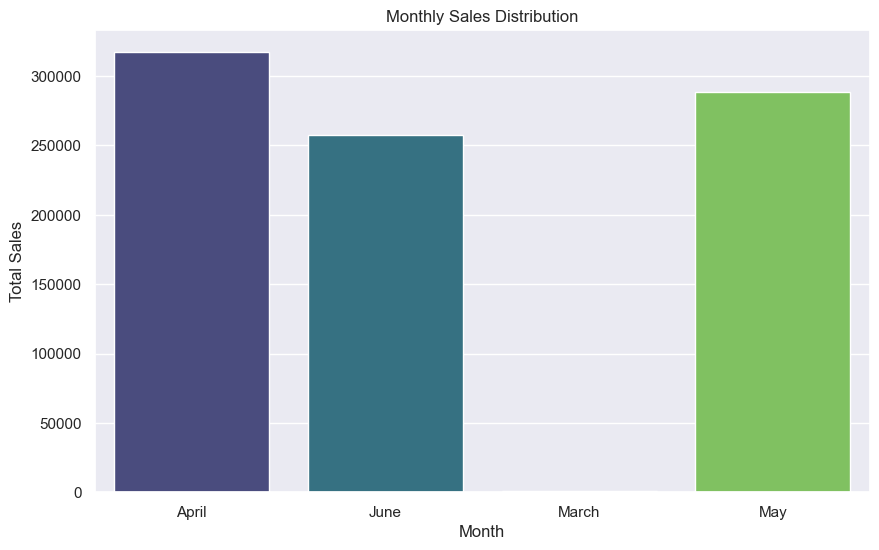

In [109]:
# 2. Monthly Sales Distribution
monthly_sales = amazon.groupby('month')['order_amount_($)'].sum()
plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette='viridis')
plt.title('Monthly Sales Distribution')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

In [110]:
# dropping March dates from the dataset
amazon = amazon[(amazon['date'].dt.month != 3)]

Month of March is irrelevant for analysis, hence we drop March

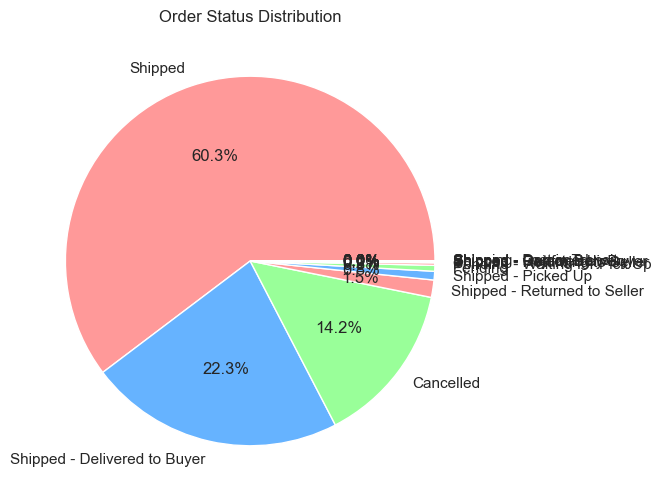

In [111]:
# 3. Order Status Distribution
order_status_dist = amazon['ship_status'].value_counts()
plt.figure(figsize=(8, 6))
order_status_dist.plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Order Status Distribution')
plt.show()

Column Value Ordering

In [112]:
# Define the desired order for the 'size' column
size_order = ['Free','XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL']

# Create an ordered categorical variable for the 'size' column
amazon['size'] = pd.Categorical(amazon['size'], categories=size_order, ordered=True)

## Visualizing Data

In [113]:
amazon.describe(include='all')

,order_ID,date,ship_status,fullfilment,service_level,style,sku,product_category,size,asin,courier_ship_status,order_quantity,order_amount_($),city,state,zip,promotion,customer_type,month
count,128797,128797,128797,128797,128797,128797,128797,128797,128797,128797,128797,128797.000000,128797.000000,128797,128797,128797,128797,128797,128797
unique,120220,NaN,13,2,2,1377,7194,9,11,7189,4,NaN,NaN,8953,70,9460,5784,2,3
top,403-4984515-8861958,NaN,Shipped,Amazon,Expedited,JNE3797,JNE3797-KR-L,Set,M,B09SDXFFQ1,Shipped,NaN,NaN,BENGALURU,MAHARASHTRA,201301.0,no promotion,customer,April
freq,12,NaN,77664,89543,88460,4221,772,50206,22679,772,109331,NaN,NaN,11200,22235,1004,49088,127926,49065
mean,NaN,2022-05-12 13:11:06.099365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.904439,6.703313,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2022-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2022-04-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,4.543000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2022-05-10 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,6.413440,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2022-06-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,8.481000,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2022-06-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,61.424000,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
amazon['date'].min(), amazon['date'].max()

(Timestamp('2022-04-01 00:00:00'), Timestamp('2022-06-29 00:00:00'))

In [115]:
amazon.isnull().sum()

order_ID               0
date                   0
ship_status            0
fullfilment            0
service_level          0
style                  0
sku                    0
product_category       0
size                   0
asin                   0
courier_ship_status    0
order_quantity         0
order_amount_($)       0
city                   0
state                  0
zip                    0
promotion              0
customer_type          0
month                  0
dtype: int64

In [116]:
amazon.nunique().to_frame(name='Count of unique values')

,Count of unique values
order_ID,120220
date,90
ship_status,13
fullfilment,2
service_level,2
style,1377
sku,7194
product_category,9
size,11
asin,7189


In [117]:
revenue_by_month = amazon.groupby('month')['order_amount_($)'].sum()
percent_decrease_apr_to_may = (revenue_by_month['April'] - revenue_by_month['May']) / revenue_by_month['April'] * 100
percent_decrease_may_to_jun = (revenue_by_month['May'] - revenue_by_month['June']) / revenue_by_month['May'] * 100
total_decrease = (revenue_by_month['April'] - revenue_by_month['June']) / revenue_by_month['April'] * 100
print(f"Total revenue for April 2022: ${revenue_by_month['April']:,.2f}")
print(f"Total revenue for May 2022: ${revenue_by_month['May']:,.2f}, which is a -{percent_decrease_apr_to_may:.2f}% decrease from April.")
print(f"Total revenue for June 2022: ${revenue_by_month['June']:,.2f}, which is a -{percent_decrease_may_to_jun:.2f}% decrease from May.")
print(f"Total revenue for Q2 2022 decreased by -{total_decrease:.2f}%")
print("\n")

revenue_by_category = amazon.groupby('product_category')['order_amount_($)'].sum().sort_values(ascending=False)
print("Total revenue by product category:")
print(revenue_by_category.apply(lambda x: "${:,.2f}".format(x)))
print("\n")

revenue_by_category = amazon.groupby('product_category')['order_amount_($)'].sum()
percent_revenue_by_category = ((revenue_by_category / revenue_by_category.sum()) * 100).sort_values(ascending=False)
percent_revenue_by_category = percent_revenue_by_category.apply(lambda x: "{:.2f}%".format(x))
print("Percentage of revenue by product category:")
print(percent_revenue_by_category)
print("\n")

avg_price_by_category = amazon.groupby('product_category')['order_amount_($)'].mean()
avg_price_by_category = avg_price_by_category.sort_values(ascending=False)
print("Top 5 product categories by average price:")
print(avg_price_by_category.head(5))
print("\n")

cancelled_orders = amazon[amazon['ship_status'].isin(['Cancelled', 'Shipped - Lost in Transit'])]
returned_orders = amazon[amazon['ship_status'].isin(['Shipped - Returned to Seller', 'Shipped - Returning to Seller', 'Shipped - Rejected by Buyer', 'Shipped - Damaged'])]
total_cancelled = len(cancelled_orders)
total_returned = len(returned_orders)
total_cancelled_returned = total_cancelled + total_returned
percent_cancelled = total_cancelled / len(amazon) * 100
percent_returned = total_returned / len(amazon) * 100
percent_cancelled_returned = total_cancelled_returned / amazon['order_quantity'].sum() * 100
print(f"Total cancelled orders: {total_cancelled}, which is {percent_cancelled:.2f}% of all orders.")
print(f"Total returned orders: {total_returned}, which is {percent_returned:.2f}% of all orders.")
print(f"This represents {percent_cancelled_returned:.2f}% of all orders.")
print("\n")


monthly_order_data = amazon.groupby(pd.Grouper(key='date', freq='ME')).agg({'order_amount_($)': 'mean', 'order_quantity': 'mean'})
monthly_order_data = monthly_order_data.rename(columns={'order_amount_($)': 'average_order_amount', 'order_quantity': 'average_order_quantity'})
print(monthly_order_data)
print("\n")

popular_category_by_state = amazon.groupby(['state', 'product_category'])['order_quantity'].sum().reset_index()
popular_category_by_state = popular_category_by_state.sort_values(['state', 'order_quantity'], ascending=[True, False])
popular_category_by_state = popular_category_by_state.drop_duplicates(subset=['state'])
print("Most popular product category in each state:")
print(popular_category_by_state)
print("\n")

avg_order_amount_by_customer_type = amazon.groupby('customer_type')['order_amount_($)'].mean()
print("Average order amount by customer type:")
print(avg_order_amount_by_customer_type.apply(lambda x: "${:,.2f}".format(x)))


Total revenue for April 2022: $317,225.79
Total revenue for May 2022: $288,469.70, which is a -9.06% decrease from April.
Total revenue for June 2022: $257,671.11, which is a -10.68% decrease from May.
Total revenue for Q2 2022 decreased by -18.77%


Total revenue by product category:
product_category
Set              $430,629.52
kurta            $233,906.97
Western Dress    $123,292.61
Top               $58,776.09
Ethnic Dress       $8,691.31
Blouse             $5,039.41
Bottom             $1,657.35
Saree              $1,363.27
Dupatta               $10.06
Name: order_amount_($), dtype: str


Percentage of revenue by product category:
product_category
Set              49.88%
kurta            27.09%
Western Dress    14.28%
Top               6.81%
Ethnic Dress      1.01%
Blouse            0.58%
Bottom            0.19%
Saree             0.16%
Dupatta           0.00%
Name: order_amount_($), dtype: str


Top 5 product categories by average price:
product_category
Set              8.577252


In [120]:
amazon.head()

,order_ID,date,ship_status,fullfilment,service_level,style,sku,product_category,size,asin,courier_ship_status,order_quantity,order_amount_($),city,state,zip,promotion,customer_type,month
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,unknown,0,7.12382,MUMBAI,MAHARASHTRA,400081.0,no promotion,customer,April
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,4.46600,BENGALURU,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,customer,April
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,3.61900,NAVI MUMBAI,MAHARASHTRA,410210.0,IN Core Free Shipping 2015/04/08 23-48-5-108,business,April
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,unknown,0,8.28663,PUDUCHERRY,PUDUCHERRY,605008.0,no promotion,customer,April
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,6.31400,CHENNAI,TAMIL NADU,600073.0,no promotion,customer,April


C:\Users\fhdaa\AppData\Local\Temp\ipykernel_26156\3943473756.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fulfillment_method.index, y=fulfillment_method.values, palette='pastel')


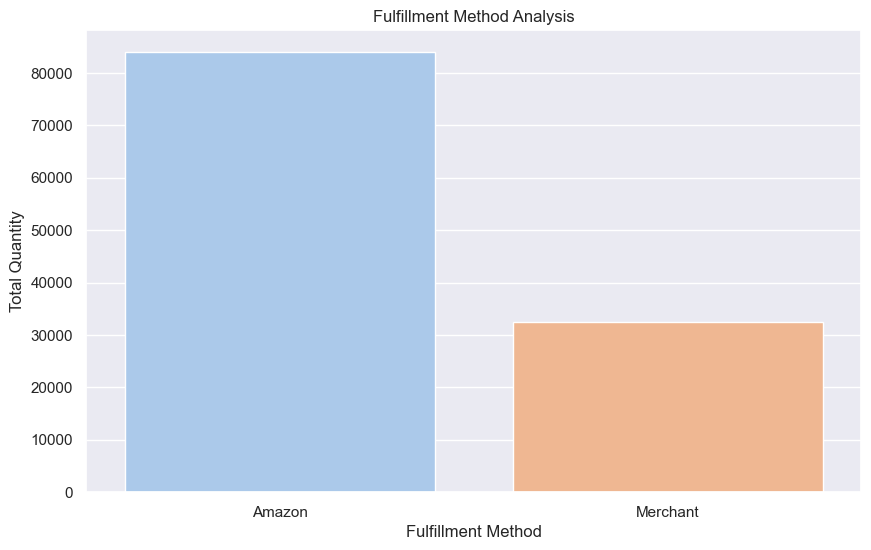

In [123]:
# 4. Fulfillment Method Analysis
fulfillment_method = amazon.groupby('fullfilment')['order_quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=fulfillment_method.index, y=fulfillment_method.values, palette='pastel')
plt.title('Fulfillment Method Analysis')
plt.xlabel('Fulfillment Method')
plt.ylabel('Total Quantity')
plt.show()

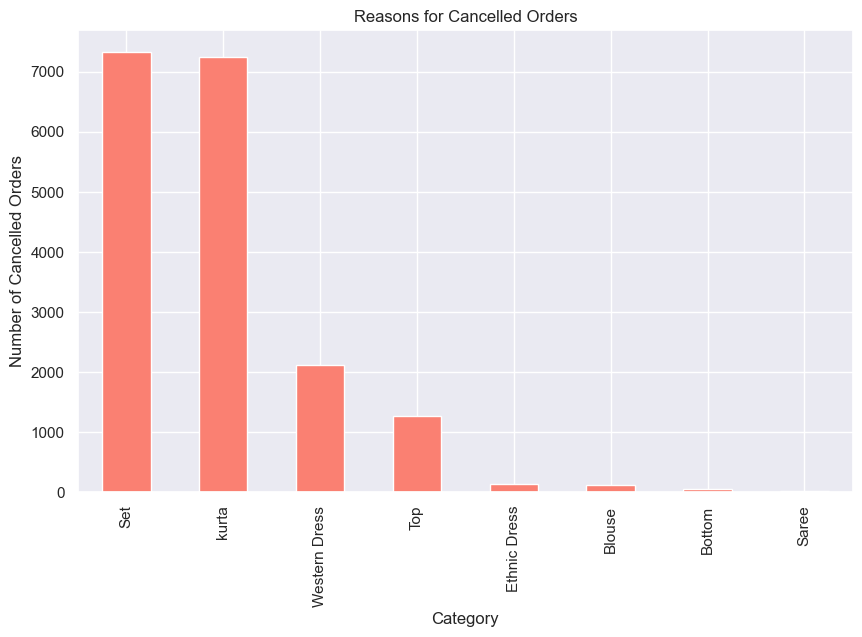

In [124]:
# 5. Cancelled Orders Analysis
cancelled_orders = amazon[amazon['ship_status'] == 'Cancelled']
cancelled_reasons = cancelled_orders.groupby('product_category')['order_quantity'].count().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
cancelled_reasons.plot.bar(color='salmon')
plt.title('Reasons for Cancelled Orders')
plt.xlabel('Category')
plt.ylabel('Number of Cancelled Orders')
plt.show()

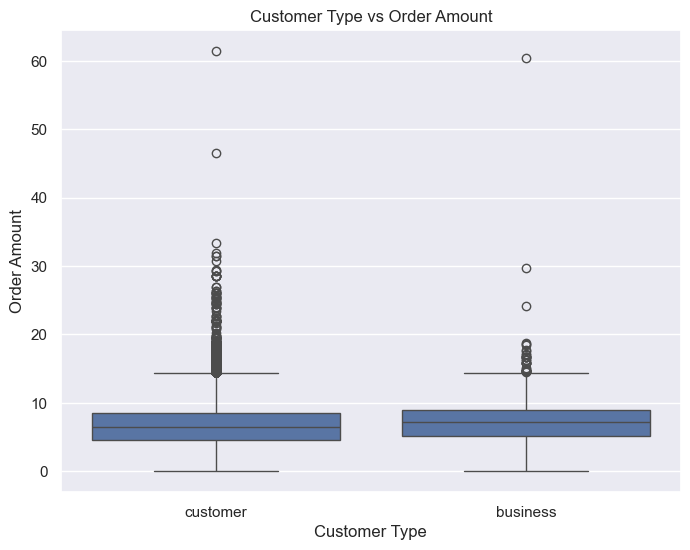

In [135]:
# 6. B2B vs. Customer Sales
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='customer_type',
    y='order_amount_($)',
    data=amazon
)
plt.title('Customer Type vs Order Amount')
plt.xlabel('Customer Type')
plt.ylabel('Order Amount')
plt.show()

C:\Users\fhdaa\AppData\Local\Temp\ipykernel_26156\3293720165.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skus.index, y=top_skus.values, palette='coolwarm')


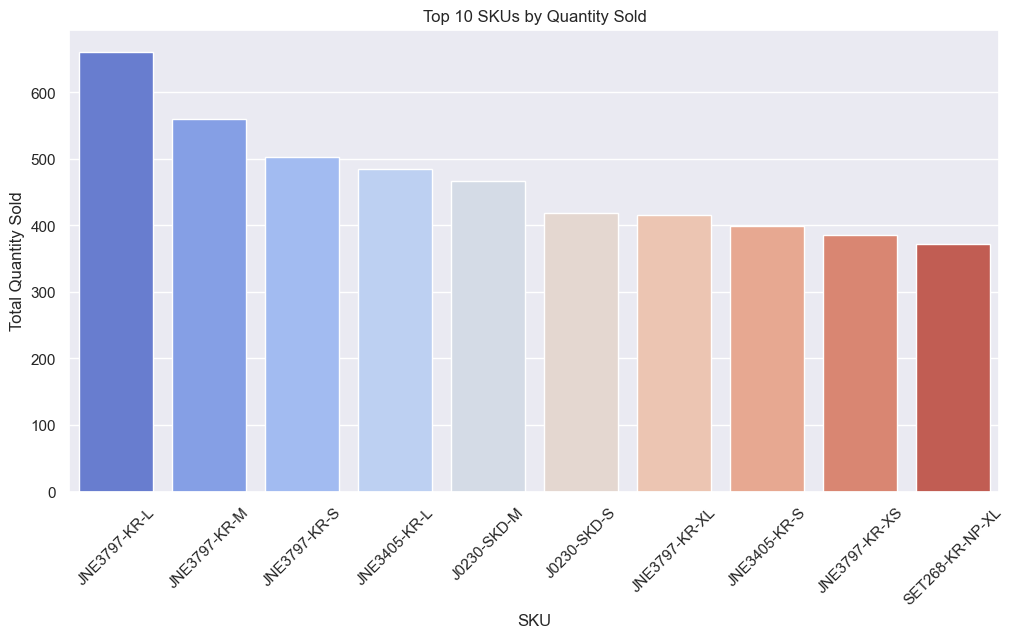

In [136]:
# 7. SKU-Level Analysis
top_skus = amazon.groupby('sku')['order_quantity'].sum().nlargest(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_skus.index, y=top_skus.values, palette='coolwarm')
plt.title('Top 10 SKUs by Quantity Sold')
plt.xlabel('SKU')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.show()

C:\Users\fhdaa\AppData\Local\Temp\ipykernel_26156\3595331427.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_amount_order.index, y=avg_amount_order.values, palette='Blues_r')


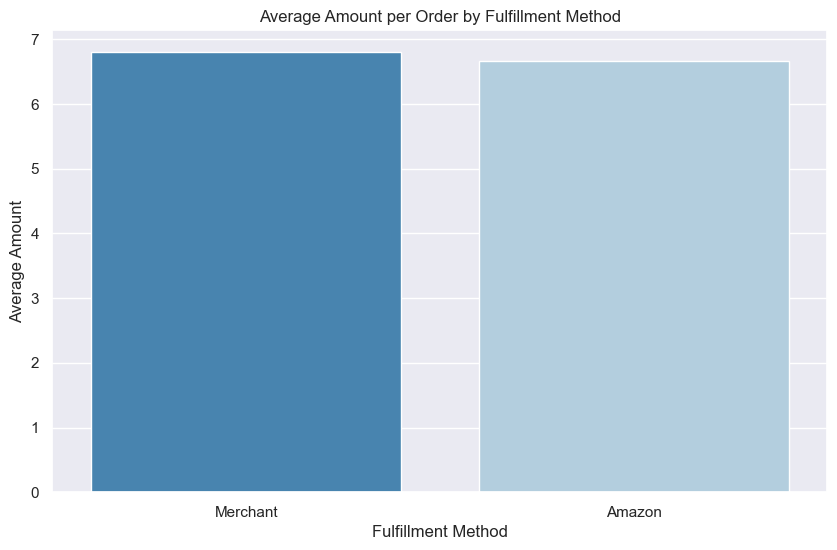

In [137]:
# 8. Average Amount per Order by Fulfillment Method
avg_amount_order = amazon.groupby('fullfilment')['order_amount_($)'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_amount_order.index, y=avg_amount_order.values, palette='Blues_r')
plt.title('Average Amount per Order by Fulfillment Method')
plt.xlabel('Fulfillment Method')
plt.ylabel('Average Amount')
plt.show()

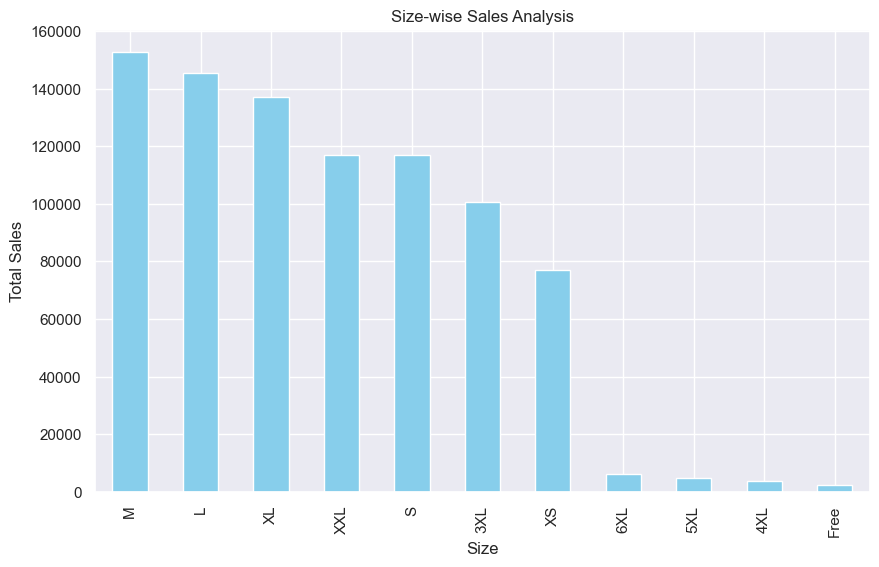

In [138]:
# 10. Size-wise Sales Analysis
size_sales = amazon.groupby('size')['order_amount_($)'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
size_sales.plot.bar(color='skyblue')
plt.title('Size-wise Sales Analysis')
plt.xlabel('Size')
plt.ylabel('Total Sales')
plt.show()

c:\Users\fhdaa\OneDrive\Documents\GitHub\DataScience-Sharpner\dsenv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\fhdaa\OneDrive\Documents\GitHub\DataScience-Sharpner\dsenv\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\fhdaa\OneDrive\Documents\GitHub\DataScience-Sharpner\dsenv\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)
c:\Users\fhdaa\OneDrive\Documents\GitHub\DataScience-Sharpner\dsenv\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=x, y=y, **kwargs)


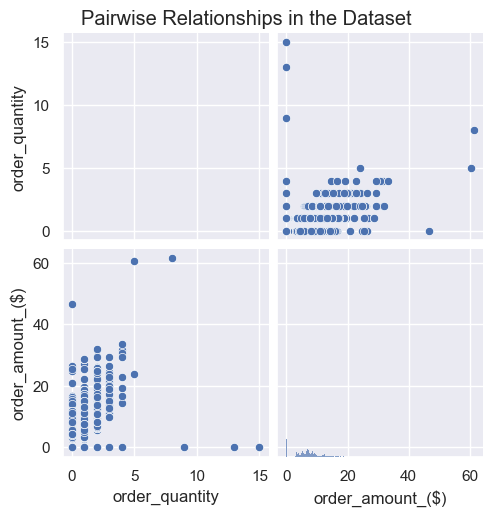

In [140]:
# 11. Pairwise Relationships in the Dataset
sns.pairplot(amazon[['order_quantity', 'order_amount_($)', 'date']], palette='husl')
plt.suptitle('Pairwise Relationships in the Dataset', y=1.02)
plt.show()

In [147]:
month_order = ['April', 'May', 'June']

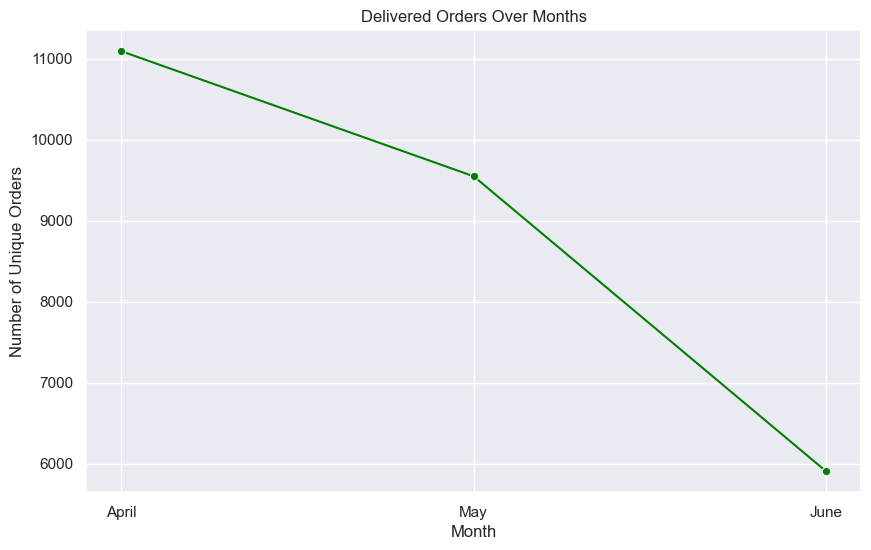

In [148]:
# 12. Customer "Retention" (actually delivered orders trend)

customer_retention = amazon[
    amazon['ship_status'] == 'Shipped - Delivered to Buyer'
].groupby('month')['order_ID'].nunique()
customer_retention = customer_retention.reindex(month_order)
plt.figure(figsize=(10, 6))

sns.lineplot(
    x=customer_retention.index,
    y=customer_retention.values,
    marker='o',
    color='green'
)

plt.title('Delivered Orders Over Months')
plt.xlabel('Month')
plt.ylabel('Number of Unique Orders')

plt.show()

C:\Users\fhdaa\AppData\Local\Temp\ipykernel_26156\1350491308.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_transaction_amount.index, y=avg_transaction_amount.values, palette='coolwarm')


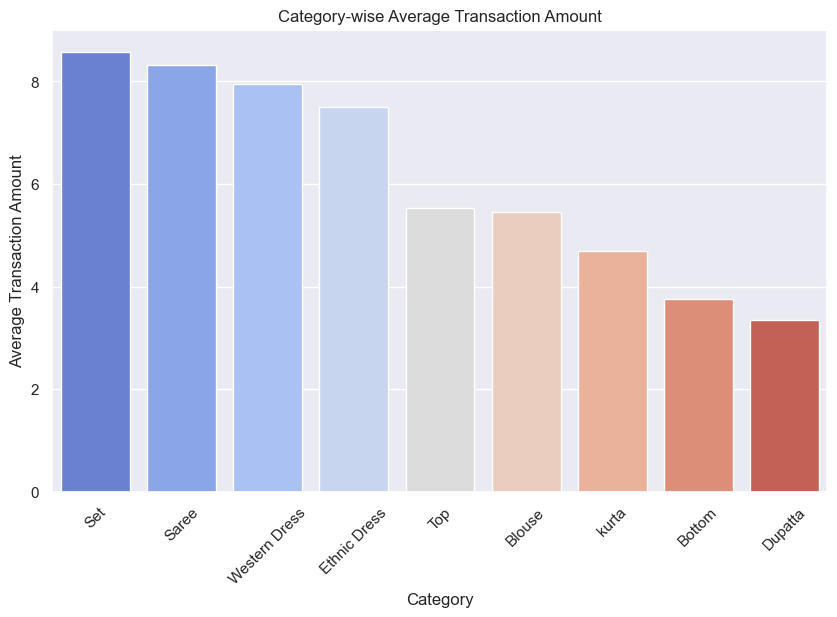

In [149]:
# 13. Category-wise Average Transaction Amount
avg_transaction_amount = amazon.groupby('product_category')['order_amount_($)'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_transaction_amount.index, y=avg_transaction_amount.values, palette='coolwarm')
plt.title('Category-wise Average Transaction Amount')
plt.xlabel('Category')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=45)
plt.show()

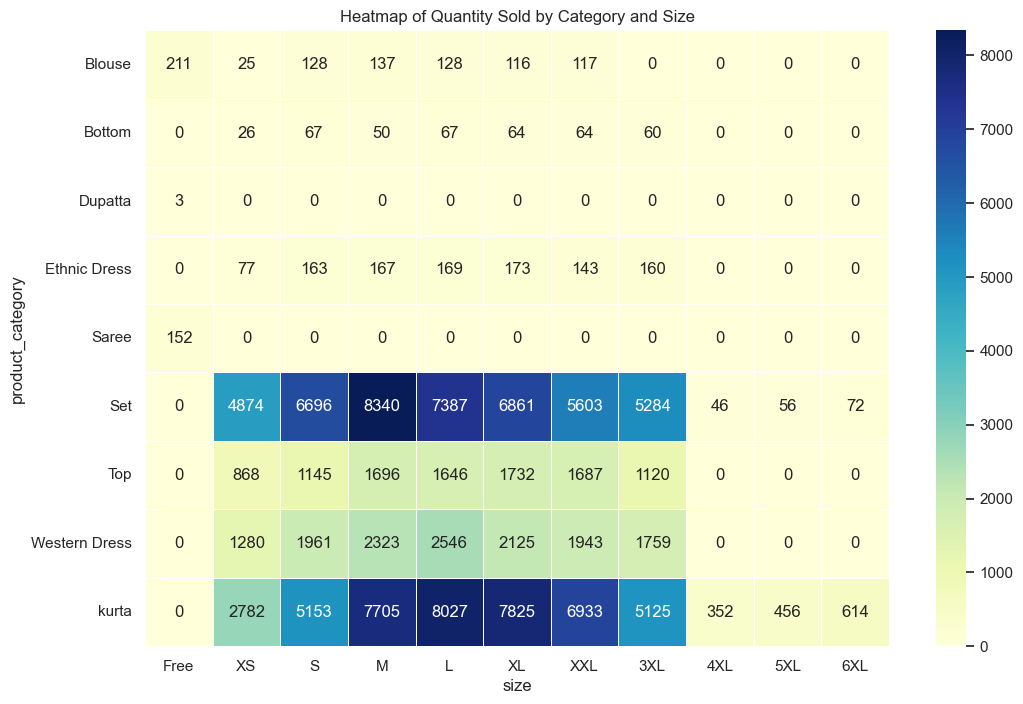

In [150]:
# 14. Heatmap of Quantity Sold by Category and Size
heatmap_data = amazon.pivot_table(index='product_category', columns='size', values='order_quantity', aggfunc='sum', fill_value=0)
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5)
plt.title('Heatmap of Quantity Sold by Category and Size')
plt.show()

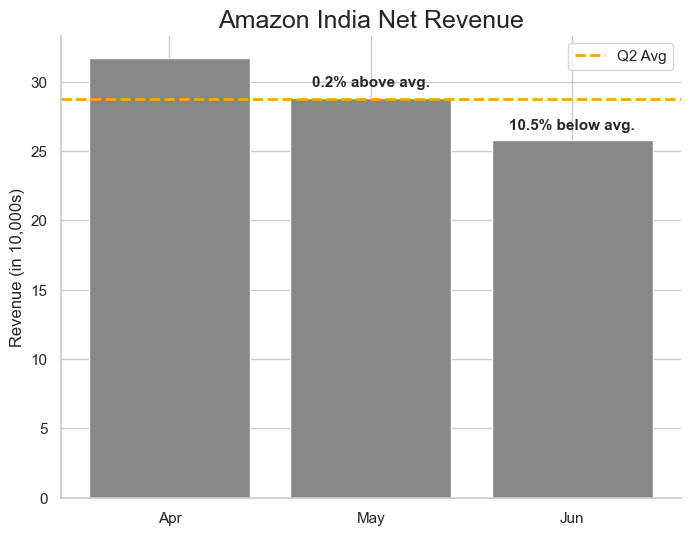

In [160]:
import matplotlib.ticker as ticker
sns.set_style('whitegrid')

# Group data
monthly_sales = amazon.groupby(
    pd.Grouper(key='date', freq='ME')
)['order_amount_($)'].sum()

# Metrics
latest_month_revenue = monthly_sales.iloc[-1]
avg_quarterly_revenue = monthly_sales.tail(3).mean()

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(monthly_sales.index.strftime('%b'), monthly_sales.values, color='#878787')

# Annotate last 2 bars
for i, bar in enumerate(bars):
    if i < len(bars) - 2:
        continue
    
    month_sales = bar.get_height()
    pct = round((1 - (month_sales / avg_quarterly_revenue)) * 100, 1)
    
    if pct < 0:
        label = f'{abs(pct):.1f}% above avg.'
    else:
        label = f'{pct:.1f}% below avg.'
    
    ax.annotate(
        label,
        xy=(bar.get_x() + bar.get_width()/2, month_sales),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Average line
ax.axhline(avg_quarterly_revenue, linestyle='--', color='orange', linewidth=2, label='Q2 Avg')

# Formatting
ax.set_title('Amazon India Net Revenue', fontsize=18)
ax.set_ylabel('Revenue (in 10,000s)', fontsize=12)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend()
plt.show()

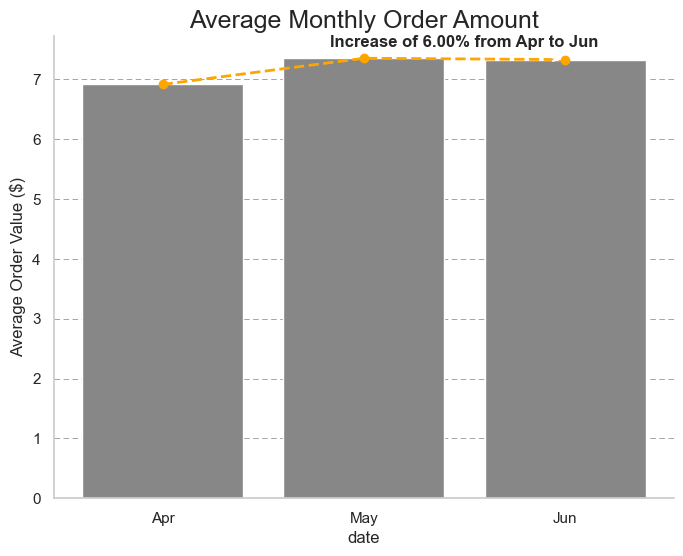

In [158]:
# Group the data by month and calculate the average order value
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Group data
monthly_aov = amazon.groupby(
    pd.Grouper(key='date', freq='ME')
).agg({
    'order_amount_($)': 'sum',
    'order_ID': 'nunique'
})

# Calculate AOV
monthly_aov['average_order_value'] = (
    monthly_aov['order_amount_($)'] / monthly_aov['order_ID']
)

# Sort by date (important)
monthly_aov = monthly_aov.sort_index()

# Percent change
monthly_aov['pct_change'] = monthly_aov['average_order_value'].pct_change() * 100

# Plot
fig, ax = plt.subplots(figsize=(8,6))

months = monthly_aov.index.strftime('%b')
values = monthly_aov['average_order_value'].values

sns.barplot(x=months, y=values, ax=ax, color='#878787')

# Line plot
ax.plot(months, values, linestyle='--', linewidth=2, color='orange', marker='o')

# Safe April → June calculation
apr_val = monthly_aov.iloc[0]['average_order_value']
jun_val = monthly_aov.iloc[-1]['average_order_value']

pct_change = ((jun_val - apr_val) / apr_val) * 100

# Dynamic annotation (no hardcoding)
ax.annotate(
    f'Increase of {pct_change:.2f}% from Apr to Jun',
    xy=(2, jun_val),
    xytext=(1.5, jun_val * 1.03),
    fontsize=12,
    fontweight='bold',
    ha='center',
    arrowprops=dict(arrowstyle='->', lw=1.5)
)

# Labels
ax.set_title('Average Monthly Order Amount', fontsize=18)
ax.set_ylabel('Average Order Value ($)', fontsize=12)

# Styling
ax.yaxis.grid(linestyle='--', color='gray', linewidth=0.5, dashes=(8, 5))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

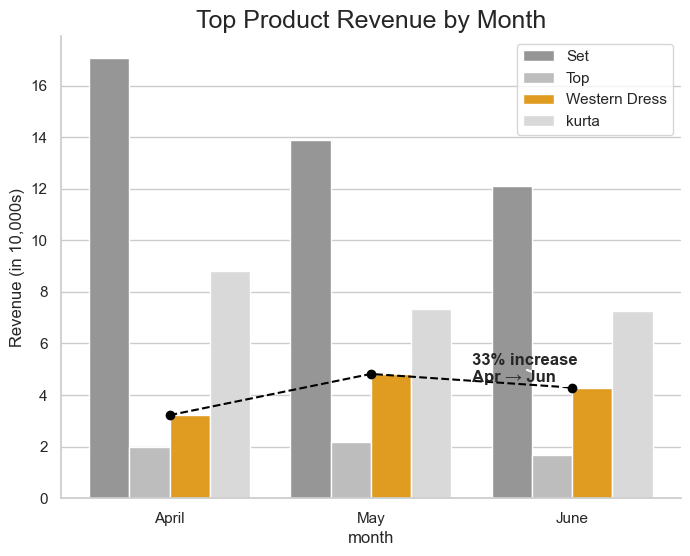

In [161]:
import warnings
warnings.filterwarnings('ignore')

fig, ax = plt.subplots(figsize=(8,6))

month_order = ['April', 'May', 'June']

# FIX: copy()
sales_data = amazon[
    amazon['product_category'].isin(['Western Dress', 'Top', 'kurta', 'Set'])
].copy()

sales_data['date'] = pd.to_datetime(sales_data['date'])
sales_data['month'] = sales_data['date'].dt.month_name()

sales_by_month = sales_data.groupby(
    ['month', 'product_category']
)['order_amount_($)'].sum().reset_index()

sales_by_month['month'] = pd.Categorical(
    sales_by_month['month'], categories=month_order, ordered=True
)

# FIX: enforce order
sns.barplot(
    x='month',
    y='order_amount_($)',
    hue='product_category',
    data=sales_by_month,
    order=month_order,
    palette=['#969696', '#bdbdbd', 'orange', '#d9d9d9'],
    ax=ax
)

# Western Dress line
sales_wd = sales_by_month[
    sales_by_month['product_category'] == 'Western Dress'
].sort_values('month').reset_index(drop=True)

x_positions = range(len(sales_wd))
ax.plot(x_positions, sales_wd['order_amount_($)'], linestyle='--', color='black', marker='o')

# FIX: correct Apr → Jun
pct_increase = (
    (sales_wd.loc[2, 'order_amount_($)'] - sales_wd.loc[0, 'order_amount_($)'])
    / sales_wd.loc[0, 'order_amount_($)']
) * 100

y_val = sales_wd.loc[2, 'order_amount_($)']

ax.annotate(
    f'{pct_increase:.0f}% increase\nApr → Jun',
    xy=(2, y_val),
    xytext=(1.5, y_val * 1.05),
    fontsize=12,
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', lw=1.5)
)

# Proper y-axis formatting
import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}'))

ax.set_title('Top Product Revenue by Month', fontsize=18)
ax.set_ylabel('Revenue (in 10,000s)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(bbox_to_anchor=(1,1))
plt.show()

warnings.filterwarnings('default')

C:\Users\fhdaa\AppData\Local\Temp\ipykernel_26156\3988540580.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


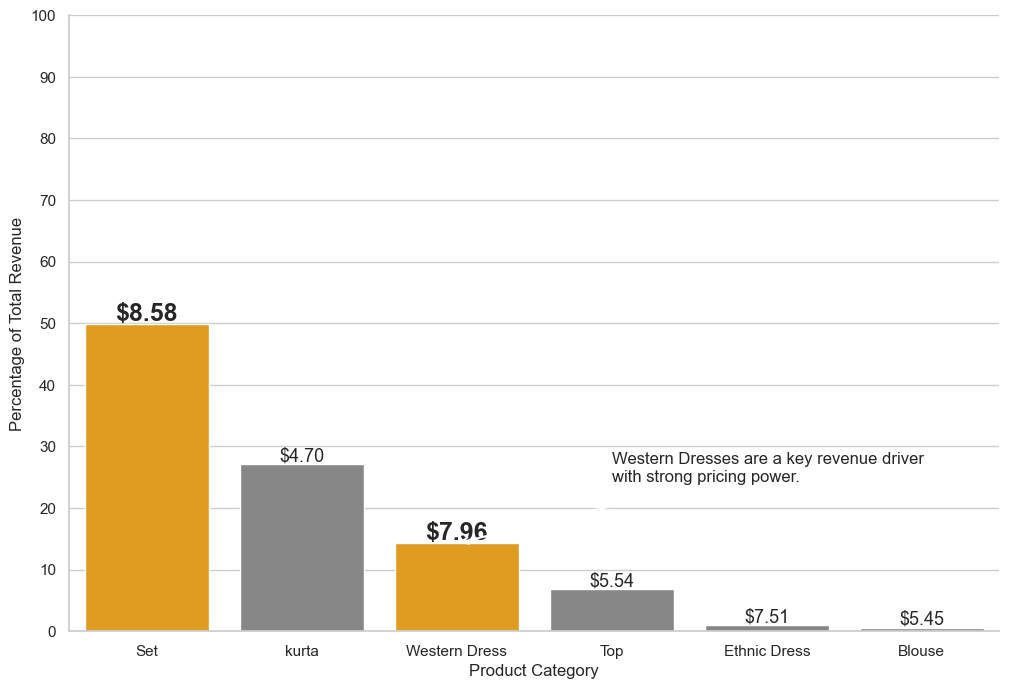

In [162]:
# Group total revenue (FULL dataset)
total_revenue = amazon['order_amount_($)'].sum()

# Category revenue
sales_by_category = amazon.groupby('product_category')['order_amount_($)'].sum()

# Filter safely
included_categories = ['Set', 'kurta', 'Western Dress', 'Top', 'Ethnic Dress', 'Blouse']
sales_by_category = sales_by_category.reindex(included_categories).dropna()

# Percent of TOTAL revenue
sales_by_category_pct = (sales_by_category / total_revenue) * 100
sales_by_category_pct = sales_by_category_pct.sort_values(ascending=False)

# Precompute avg cost (FAST)
avg_costs = amazon.groupby('product_category')['order_amount_($)'].mean()

# Plot
fig, ax = plt.subplots(figsize=(12,8))

palette_colors = [
    'orange' if cat in ['Set', 'Western Dress'] else '#878787'
    for cat in sales_by_category_pct.index
]

sns.barplot(
    x=sales_by_category_pct.index,
    y=sales_by_category_pct.values,
    ax=ax,
    palette=palette_colors
)

# Axis
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.set_ylabel('Percentage of Total Revenue')
ax.set_xlabel('Product Category')

# Labels
for i, category in enumerate(sales_by_category_pct.index):
    avg_cost = avg_costs[category]
    
    fontsize = 18 if category in ['Set', 'Western Dress'] else 13
    
    ax.text(
        i,
        sales_by_category_pct.values[i] + 0.5,
        f'${avg_cost:.2f}',
        ha='center',
        fontsize=fontsize,
        fontweight='bold' if fontsize == 18 else None
    )

# Callout
western_sales = sales_by_category_pct['Western Dress']
western_index = sales_by_category_pct.index.get_loc('Western Dress')

ax.annotate(
    'Western Dresses are a key revenue driver\nwith strong pricing power.',
    xy=(western_index, western_sales),
    xytext=(western_index + 1, western_sales + 10),
    arrowprops=dict(arrowstyle='->', lw=1.5),
    fontsize=12
)

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

C:\Users\fhdaa\AppData\Local\Temp\ipykernel_26156\1623352708.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


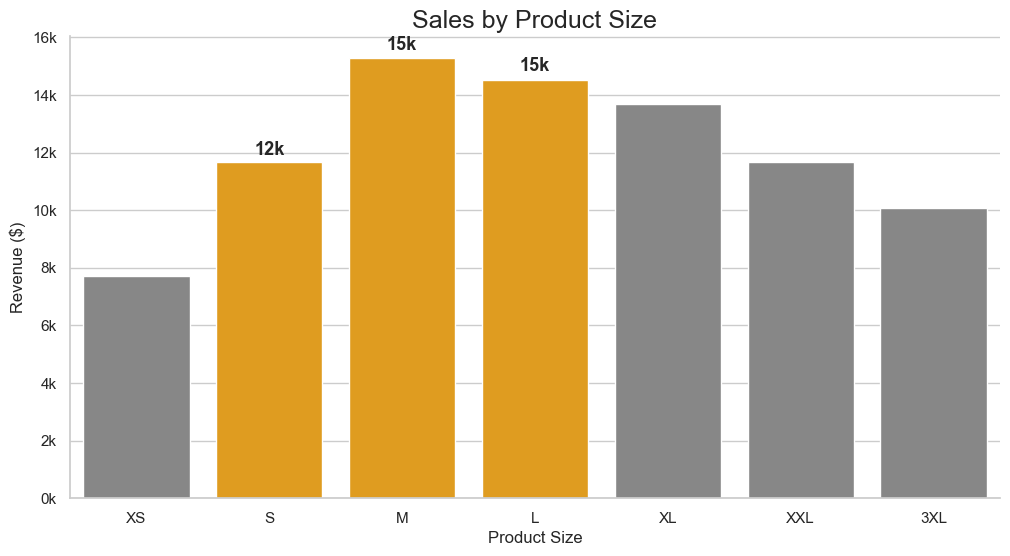

In [163]:
import matplotlib.ticker as ticker

# Group data
sales_by_size = amazon.groupby('size')['order_amount_($)'].sum()

# Logical order
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL']
sales_by_size = sales_by_size.reindex(size_order).dropna()

# Plot
fig, ax = plt.subplots(figsize=(12,6))

palette_colors = [
    'orange' if size in ['S', 'M', 'L'] else '#878787'
    for size in sales_by_size.index
]

sns.barplot(
    x=sales_by_size.index,
    y=sales_by_size.values,
    ax=ax,
    palette=palette_colors
)

# Labels
ax.set_xlabel('Product Size', fontsize=12)
ax.set_ylabel('Revenue ($)', fontsize=12)
ax.set_title('Sales by Product Size', fontsize=18)

# Proper y-axis formatting
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}k')
)

# Highlight annotations
for i, size in enumerate(sales_by_size.index):
    if size in ['S', 'M', 'L']:
        y_val = sales_by_size.values[i]
        ax.text(
            i,
            y_val * 1.02,
            f'{y_val/10000:.0f}k',
            ha='center',
            fontsize=13,
            fontweight='bold'
        )

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

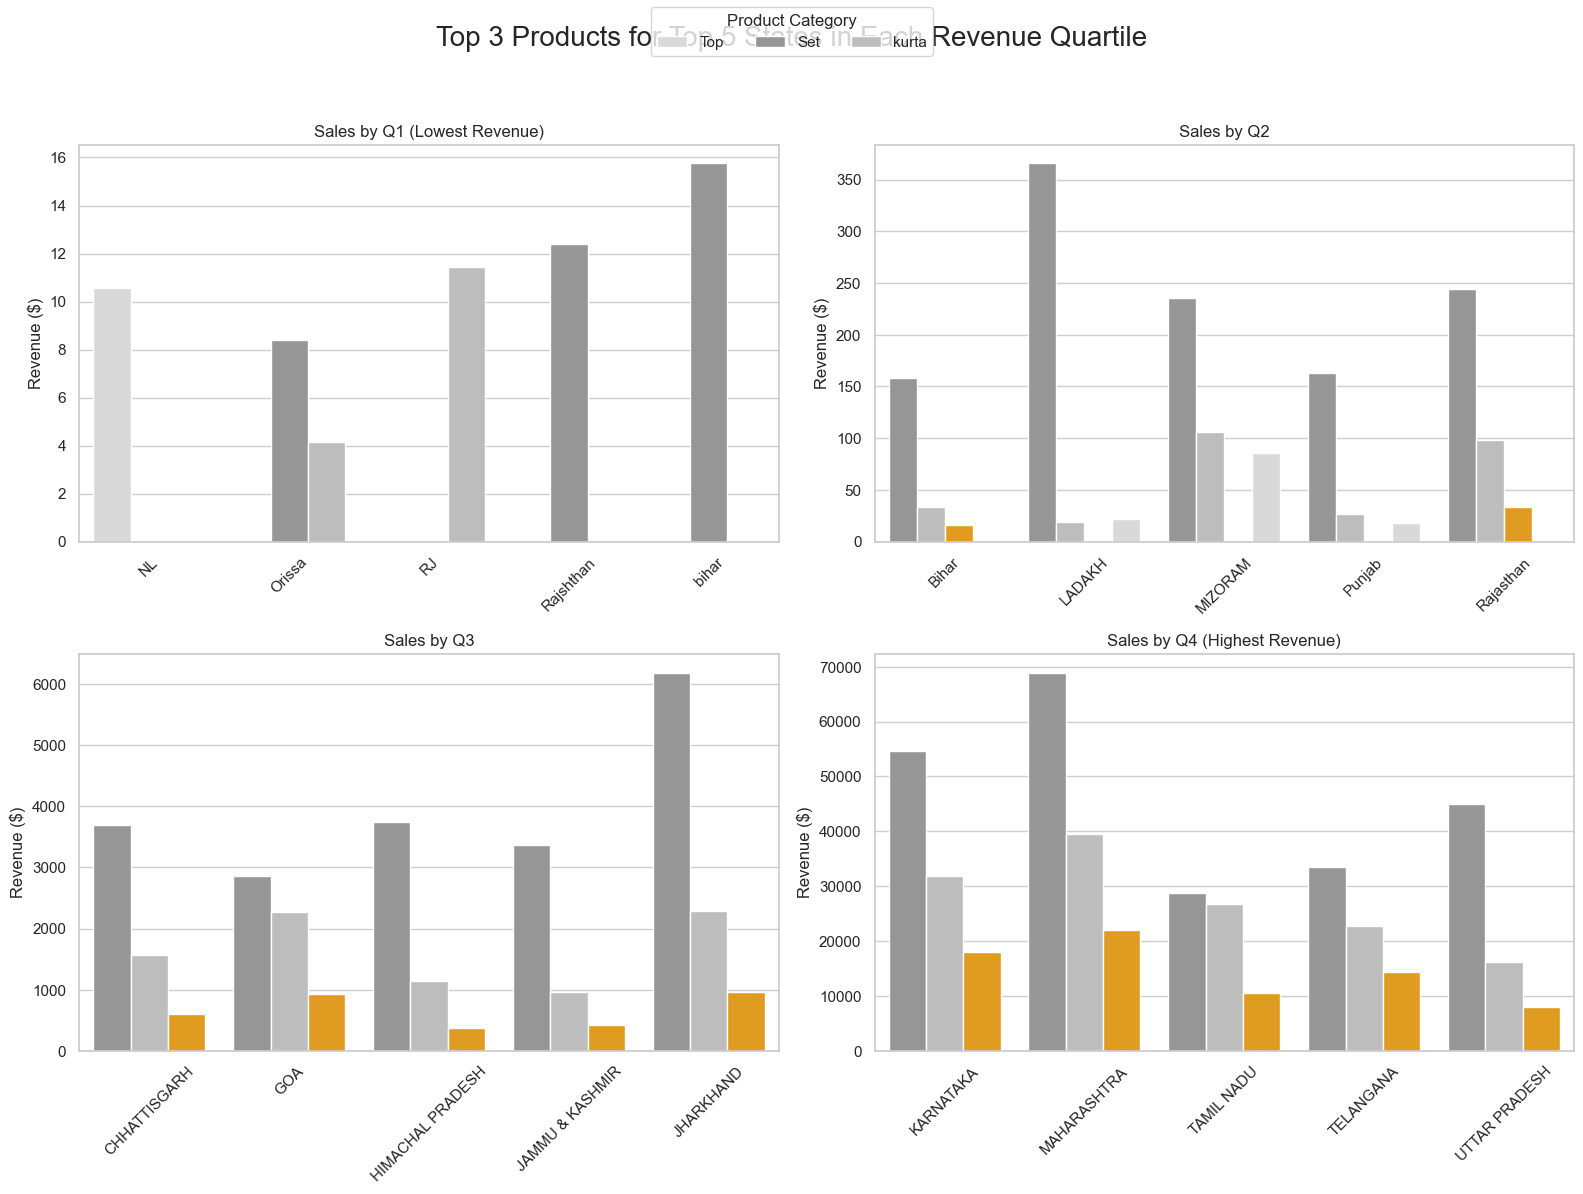

In [164]:
# --- Setup ---
colors = {
    'Top': '#d9d9d9',
    'Set': '#969696',
    'kurta': '#bdbdbd',
    'Western Dress': 'orange'
}

# --- State-level revenue ---
sales_by_state = amazon.groupby('state')['order_amount_($)'].sum()

# Assign quartiles
quartiles = pd.qcut(sales_by_state, 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Combine into dataframe
state_df = pd.DataFrame({
    'state': sales_by_state.index,
    'revenue': sales_by_state.values,
    'quartile': quartiles.values
})

# --- Get top 5 states per quartile ---
top_states = (
    state_df.sort_values(['quartile', 'revenue'], ascending=[True, False])
    .groupby('quartile')
    .head(5)
)

# --- Filter main data ---
filtered = amazon[amazon['state'].isin(top_states['state'])]

# --- Sales by state + product ---
sales_state_prod = (
    filtered.groupby(['state', 'product_category'])['order_amount_($)']
    .sum()
    .reset_index()
)

# --- Get top 3 products per state ---
top_products_df = (
    sales_state_prod.sort_values(['state', 'order_amount_($)'], ascending=[True, False])
    .groupby('state')
    .head(3)
)

# --- Merge quartile info ---
top_products_df = top_products_df.merge(
    top_states[['state', 'quartile']],
    on='state'
)

# --- Plot ---
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

quartile_list = ['Q1', 'Q2', 'Q3', 'Q4']
titles = [
    'Q1 (Lowest Revenue)',
    'Q2',
    'Q3',
    'Q4 (Highest Revenue)'
]

for i, q in enumerate(quartile_list):
    ax = axs[i//2, i%2]
    
    data = top_products_df[top_products_df['quartile'] == q]
    
    sns.barplot(
        x='state',
        y='order_amount_($)',
        hue='product_category',
        data=data,
        palette=colors,
        ax=ax
    )
    
    ax.set_title(f'Sales by {titles[i]}')
    ax.set_xlabel('')
    ax.set_ylabel('Revenue ($)')
    
    ax.legend().set_visible(False)
    
    # Rotate labels
    for label in ax.get_xticklabels():
        label.set_rotation(45)

# Shared legend
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels), title='Product Category')

plt.suptitle("Top 3 Products for Top 5 States in Each Revenue Quartile", fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()